# CSC3043S Reasoning in AI: Large Language Models

# Tutorial 1: Tokenization and the Transformer LLM Architecture

**Author: Jan Buys**

**Introduction**

In this notebook we build a modern decoder-only Transformer language model from scratch and train
it on [TinyStories](https://arxiv.org/abs/2305.07759), a dataset of simple synthetic children's
stories. We start by tokenizing raw text into token indices with a
byte-pair encoding (BPE) tokenizer that we train ourselves — and end by generating new stories from
our trained model.

The architecture we build is *not* the original 2017 Transformer. It is the standard modern dense
LLM configuration shared (with minor variations) by many recent LLMs:
pre-norm blocks with RMSNorm, rotary position embeddings, QK norm, and a SwiGLU feed-forward
network. 

This notebook provides skeleton code that you are encouraged to complete as part of your learning
process. Look for code cells containing `TODO` to complete. Every component is followed by a test
cell that checks a property the component must satisfy — run these as you go, and do not move on
until they pass.

This tutorial covers the *core model components* and just enough training machinery to see the model
learn. The assignment that follows will builds on exactly this code and add the parts we deliberately
leave out here: more sophisticated optimisation for model training (the AdamW optimiser, learning-rate 
warmup and cosine decay, gradient clipping), an optimised BPE trainer, inference machinery (a KV cache 
and grouped-query attention), and a proper set of training experiments. 
So we use a plain SGD training loop here — it works, but you will see its limitations.

**Aims/Learning Objectives:**

* Train a character-level BPE tokenizer with a straightforward (unoptimised) implementation, and use
  it to encode and decode text.
* Explain and implement each component that distinguishes a modern LLM from the original
  Transformer, and state *why* each change was made.
* Assemble the components into a complete Transformer language model and account for its parameters.
* Implement a batched data loader, checkpointing, and a training loop, and train the model on
  TinyStories.
* Generate text with temperature sampling, and explain how the choice of temperature changes the
  output.

**Prerequisites:**

* Lecture 2 (Tokenization) and Lecture 3 (Transformer architecture for LLMs).
* Familiarity with PyTorch (`nn.Module`, `nn.Linear`, `nn.Embedding`, training loops).
* Understanding of softmax, cross-entropy loss, and gradient descent.
* Comfort with matrix multiplication and tensor shapes.

**Outline:**

* [1. The TinyStories Dataset](#section1)
* [2. Byte-Pair Encoding](#section2)
    * [2.1 Pre-tokenization](#section2_1)
    * [2.2 Learning the Merges](#section2_2)
    * [2.3 Encoding and Decoding](#section2_3)
    * [2.4 Training a Tokenizer on TinyStories](#section2_4)
    * [2.5 Encoding the Corpus](#section2_5)
* [3. The Modern Transformer LM](#section3)
    * [3.1 RMSNorm](#section3_1)
    * [3.2 SwiGLU Feed-Forward Network](#section3_2)
    * [3.3 Rotary Position Embeddings](#section3_3)
    * [3.4 Scaled Dot-Product Attention](#section3_4)
    * [3.5 Causal Multi-Head Self-Attention with QK Norm](#section3_5)
    * [3.6 The Pre-Norm Transformer Block](#section3_6)
    * [3.7 The Full Transformer LM](#section3_7)
* [4. Training](#section4)
    * [4.1 Batched Data Loader](#section4_1)
    * [4.2 Checkpointing](#section4_2)
    * [4.3 The Training Loop](#section4_3)
    * [4.4 Training the Model](#section4_4)
* [5. Text Generation](#section5)
* [6. Summary and Next Steps](#section6)

## Imports, Installations, and Downloads

This notebook uses standard machine learning libraries:

* `torch`, `torch.nn`, `torch.nn.functional` — model definition and tensor operations
* `numpy` — the tokenized corpus is stored as a numpy array of token IDs
* `matplotlib` — plot loss curves
* `re` — the pre-tokenizer regular expression
* `collections.Counter` — counting pre-tokens and symbol pairs during BPE training
* `urllib` / `os` / `time` — downloading and caching the dataset, and timing

We standard PyTorch building blocks like `nn.Linear`, `nn.Embedding`,
`F.softmax` and `F.cross_entropy`, but implement the actual transformer architecture step by step.

In [1]:
%matplotlib inline
import os
import re
import time
import math
import urllib.request
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
torch.manual_seed(42)

# Prefer a GPU if one is available. On an Apple Silicon Mac, 'mps' is Apple's Metal backend.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


<a id='section1'></a>
# 1. The TinyStories Dataset

[TinyStories](https://arxiv.org/abs/2305.07759) is a corpus of short synthetic stories generated by
GPT-3.5/GPT-4, restricted to the vocabulary of a typical 3–4 year old. It was designed to answer a
research question: how small can a language model be and still produce fluent, coherent English?
The answer turned out to be *surprisingly small*, which makes it an ideal dataset for us — we can
train a model that writes readable stories in minutes on a laptop.

The full training split contains about **2.1 million stories**. For the tutorial, we only work with a
few thousand stories from the validation split.
The validation split download is about 22 MB and is cached in a local `data/` directory.

In [3]:
os.makedirs("data", exist_ok=True)
TINYSTORIES_URL = ("https://huggingface.co/datasets/roneneldan/TinyStories/"
                   "resolve/main/TinyStoriesV2-GPT4-valid.txt")
TINYSTORIES_PATH = "data/TinyStoriesV2-GPT4-valid.txt"

if not os.path.exists(TINYSTORIES_PATH):
    print("Downloading TinyStories (~22 MB) ...")
    urllib.request.urlretrieve(TINYSTORIES_URL, TINYSTORIES_PATH)
    print(f"Downloaded to {TINYSTORIES_PATH}")
else:
    print(f"Loaded from cache: {TINYSTORIES_PATH}")

with open(TINYSTORIES_PATH, encoding="utf-8") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")

Downloaded to data/TinyStoriesV2-GPT4-valid.txt
Total characters: 22,493,387


Documents are separated by `<|endoftext|>`. We split on it, then reserve some documents for
training the tokenizer and the model, and some for validation.

We use a **subset** of the data so that everything in this notebook runs quickly. Our BPE
implementation in Section 2 is unoptimised, so it is the slowest part of the pipeline. Feel
free to increase `NUM_TRAIN_DOCS` later and see how the tokenizer and the model change.

In [ ]:
END_OF_TEXT = "<|endoftext|>"

documents = raw_text.split(END_OF_TEXT)
print(f"Number of documents: {len(documents):,}")

NUM_TRAIN_DOCS = 5000
NUM_VAL_DOCS = 500

train_text = END_OF_TEXT.join(documents[:NUM_TRAIN_DOCS])
val_text = END_OF_TEXT.join(documents[NUM_TRAIN_DOCS:NUM_TRAIN_DOCS + NUM_VAL_DOCS])

print(f"Train text: {len(train_text):,} characters")    
print(f"Val text:   {len(val_text):,} characters")
print(f"\nAn example story:\n{documents[1].strip()[:600]}")

Number of documents: 27,631
Train text: 4,059,671 characters
Val text:   407,374 characters

An example story:
Once upon a time, in a warm and sunny place, there was a big pit. A little boy named Tom liked to play near the pit. One day, Tom lost his red ball. He was very sad.
Tom asked his friend, Sam, to help him search for the ball. They looked high and low, but they could not find the ball. Tom said, "I think my ball fell into the pit."
Sam and Tom went close to the pit. They were scared, but they wanted to find the red ball. They looked into the pit, but it was too dark to see. Tom said, "We must go in and search for my ball."
They went into the pit to search. It was dark and scary. They could not 


<a id='section2'></a>
# 2. Byte-Pair Encoding

A language model processes a sequence of tokens $w_1, w_2, \ldots, w_n$, where each token comes from
a fixed vocabulary $V$ and is represented by its index into that vocabulary. **Tokenization** is the
task of converting a string into such a sequence of token indices.

Recall the trade-off from Lecture 2. A good tokenizer converts strings into a *compact* sequence of
tokens without making the vocabulary *too large*. 

Byte-pair encoding gets the best of both. It has two parts:

* a **type learner** that takes a raw training corpus and induces a vocabulary, and
* a **token segmenter** that takes new text and tokenizes it according to that vocabulary.

> **Character-level vs. byte-level.** Production tokenizers run BPE over **UTF-8 bytes**, so the initial vocabulary is exactly the
> 256 byte values and *any* string can be encoded. In this tutorial we run BPE over **Unicode
> characters** instead. The algorithm is identical, but the code is easier to read and debug
> because the intermediate symbols are readable strings rather than `bytes` objects. The one thing
> we give up is guaranteed coverage: a character never seen during training has no vocabulary
> entry, so we need an "unknown" token to fall back on.

<a id='section2_1'></a>
## 2.1 Pre-tokenization

The first step in applying a tokenizer is **pre-tokenization**: a coarse split of the text, usually
on whitespace and punctuation boundaries. We do this for two reasons:

1. **Efficiency.** Instead of scanning the whole corpus for adjacent symbol pairs, we count how
   often each distinct *pre-token* occurs, and work with that frequency table. The word `"text"`
   might appear 10,000 times in the corpus, but we only have to look at it once and weight it by
   10,000.
2. **Quality.** Merges are never allowed to cross pre-token boundaries, so we never learn a token
   that spans a word boundary in a way that glues unrelated words together.

Because merges cannot cross pre-token boundaries, the pre-tokenizer must record *where the word
boundaries were* — otherwise we could not reconstruct the spaces when decoding.
We mark the start of each word with a special symbol. Instead of a standard `_`,
we use the character `▁` (U+2581, "lower one eighth block"), which is exactly what SentencePiece and
the Llama tokenizers use. Using a dedicated character rather than a plain underscore avoids the 
ambiguity of represnting underscores that occur in real text.

Following the example from the lecture:

```
This is a newly spoken sentence.
                 |
                 v  (pre-tokenize)
▁This ▁is ▁a ▁newly ▁spoken ▁sentence .
                 |
                 v  (apply BPE)
▁Th is ▁is ▁a ▁new ly ▁spok en ▁se ntence .
```

Note that the full stop gets no `▁` marker, because no space preceded it. That is how decoding knows
to write `sentence.` rather than `sentence .`.

Our pre-tokenizer regex keeps runs of alphanumeric characters together (`\w+`) and makes every other
non-whitespace character its own pre-token (`[^\w\s]`).
The leading `(\s*)` captures any whitespace before the pre-token, which is what tells us whether a
new word is starting.

In [5]:
WORD_START = "▁"      # ▁ marks the start of a word (written '_' in the lecture slides)
UNK = "<|unk|>"            # fallback for characters not seen during tokenizer training

PRETOKEN_RE = re.compile(r"(\s*)(\w+|[^\w\s])")


def pretokenize(text):
    """
    Split text into pre-tokens, marking the start of each word with WORD_START.
    params:
        text: a string (one document, with special tokens already removed)
    returns:
        list of pre-token strings
    """
    pretokens = []
    for match in PRETOKEN_RE.finditer(text):
        whitespace, body = match.group(1), match.group(2)
        # A pre-token starts a new word if whitespace came before it. We treat the start of a
        # document as if it were preceded by a space, so that the first word is marked too.
        starts_word = bool(whitespace) or match.start() == 0
        pretokens.append(WORD_START + body if starts_word else body)
    return pretokens


print(pretokenize("This is a newly spoken sentence."))
print(pretokenize("Once upon a time, Tom didn't want to go!"))

['▁This', '▁is', '▁a', '▁newly', '▁spoken', '▁sentence', '.']
['▁Once', '▁upon', '▁a', '▁time', ',', '▁Tom', '▁didn', "'", 't', '▁want', '▁to', '▁go', '!']


Notice how `didn't` becomes `▁didn`, `'`, `t`: the apostrophe and the `t` carry no word-start
marker, so decoding will correctly re-join them with no spaces. Whitespace runs are normalised to
a single space by this scheme, so line breaks inside a story will not survive a round trip. A
byte-level tokenizer does not have that limitation, since it represents the newline byte explicitly.

Now we count pre-tokens across the corpus. Special tokens such as `<|endoftext|>` are **hard
boundaries**: we split the corpus on them first, so no merge can ever span a document boundary, and
the special token itself never contributes to the pair counts.

In [6]:
def count_pretokens(text, special_tokens=(END_OF_TEXT,)):
    """
    Count how often each pre-token occurs in the corpus.
    params:
        text:           the raw training corpus
        special_tokens: strings that act as hard boundaries (never merged across)
    returns:
        Counter mapping pre-token string -> count
    """
    counts = Counter()
    split_pattern = "|".join(re.escape(s) for s in special_tokens)
    for document in re.split(split_pattern, text):
        counts.update(pretokenize(document))
    return counts


_toy_corpus = ("low low low low low\n"
               "lower lower widest widest widest\n"
               "newest newest newest newest newest newest")
print(count_pretokens(_toy_corpus))

Counter({'▁newest': 6, '▁low': 5, '▁widest': 3, '▁lower': 2})


This reproduces the frequency table from the lecture's worked example (`low: 5, lower: 2,
widest: 3, newest: 6`), with our word-start markers attached. We will use this toy corpus to check
our merge learner in the next section.

<a id='section2_2'></a>
## 2.2 Learning the Merges

Here is the type learner algorithm as given in the lecture:

> * Start with a vocabulary consisting of all individual characters, and represent the corpus as
>   sequences of items from this vocabulary.
> * Repeat until $k$ merges have been done:
>     * Choose the two symbols that are most frequently adjacent in the training corpus (say `A`, `B`)
>     * Add a new merged symbol `AB` to the vocabulary
>     * Replace every adjacent `A` `B` in the corpus with `AB`

The final vocabulary size is therefore

$$|V| = (\text{number of special tokens}) + (\text{number of distinct characters}) + k$$

so choosing a target vocabulary size fixes the number of merges $k$.

Implementation details:

* **Ties.** Several pairs can share the highest count. We break ties by taking the
  **lexicographically greatest** pair. Any consistent rule works; what matters is that it is
  *deterministic*, so that training the tokenizer twice on the same corpus gives the same result.
* **Efficiency.** We recount every pair from scratch on every iteration. This is the naive
  $O(k \cdot N)$ algorithm which is wasteful: merging `("s", "t")` only changes the
  counts of pairs that overlap an occurrence of `st`, so almost all of the recomputation is
  redundant. In the assignment you will make this incremental. Here, the code
  should look exactly like the algorithm above.

We write two small helpers first.

In [7]:
def count_pairs(word_freqs):
    """
    Count how often each adjacent pair of symbols occurs, weighted by pre-token frequency.
    params:
        word_freqs: dict mapping a pre-token (tuple of symbol strings) -> its corpus count
    returns:
        Counter mapping (left_symbol, right_symbol) -> total count
    """
    pair_counts = Counter()
    for symbols, freq in word_freqs.items():
        for pair in zip(symbols, symbols[1:]):
            pair_counts[pair] += freq
    return pair_counts

In [8]:
def merge_word(symbols, pair):
    """
    Replace every occurrence of `pair` in `symbols` with the single merged symbol.
    E.g. merge_word(("n", "e", "w", "e", "s", "t"), ("s", "t")) -> ("n", "e", "w", "e", "st")
    params:
        symbols: tuple of symbol strings representing one pre-token
        pair:    (left, right) tuple of symbols to merge
    returns:
        new tuple of symbols
    """
    merged = []
    i = 0
    while i < len(symbols):
        # If the pair starts here, append the concatenated symbol and skip forward by 2.
        if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
            merged.append(symbols[i] + symbols[i + 1])
            i += 2
        # Otherwise keep the current symbol and advance by 1.
        else:
            merged.append(symbols[i])
            i += 1
    return tuple(merged)

In [9]:
def train_bpe(text, vocab_size, special_tokens=(END_OF_TEXT, UNK), verbose=False):
    """
    Train a character-level BPE tokenizer (unoptimised reference implementation).
    params:
        text:           raw training corpus
        vocab_size:     desired final vocabulary size
        special_tokens: tokens added to the vocabulary before anything else
        verbose:        print progress every 200 merges
    returns:
        vocab:  dict mapping token ID -> token string
        merges: list of (left, right) pairs, in the order they were learned
    """
    # Represent each distinct pre-token as a tuple of single characters, with its corpus count.
    pretoken_counts = count_pretokens(text)
    word_freqs = {tuple(pretoken): count for pretoken, count in pretoken_counts.items()}

    # Initial vocabulary: the special tokens, then every character seen in the corpus.
    characters = sorted({ch for word in word_freqs for ch in word})
    vocab = list(special_tokens) + characters
    merges = []

    num_merges = vocab_size - len(vocab)
    if num_merges < 0:
        raise ValueError(f"vocab_size={vocab_size} is smaller than the {len(vocab)} "
                         f"special tokens + characters")
    if verbose:
        print(f"{len(word_freqs):,} distinct pre-tokens, {len(characters)} characters, "
              f"{num_merges} merges to learn")

    start = time.time()
    for step in range(num_merges):
        # Step 1: count every adjacent pair of symbols in the corpus.
        pair_counts = count_pairs(word_freqs)
        if not pair_counts:
            break

        # Step 2: pick the most frequent pair, breaking ties lexicographically-greatest.
        best_count = max(pair_counts.values())
        best_pair = max(pair for pair, count in pair_counts.items() if count == best_count)

        # Step 3: apply the merge everywhere in the corpus.
        word_freqs = {merge_word(word, best_pair): freq for word, freq in word_freqs.items()}

        # Step 4: record the merge and add the new symbol to the vocabulary.
        merges.append(best_pair)
        vocab.append(best_pair[0] + best_pair[1])

        if verbose and (step + 1) % 200 == 0:
            print(f"  merge {step + 1:5d}: {best_pair[0]!r} + {best_pair[1]!r} -> "
                  f"{vocab[-1]!r} (count {best_count:,})   [{time.time() - start:.1f}s]")

    return {i: token for i, token in enumerate(vocab)}, merges

Let us check the merge learner against the toy corpus from the lecture. With 6 merges we should see
`s t` and `e st` learned first — matching the lecture, where `('e','s')` and `('s','t')` are tied at
count 9 and the tie is broken in favour of the lexicographically greater `('s','t')`.

The remaining merges differ slightly from the version in the slides because our word-start markers
change the counts: `▁l` occurs 7 times (5 in `▁low` plus 2 in `▁lower`), which is more frequent than
any pair the unmarked version would find.

In [10]:
_toy_vocab, _toy_merges = train_bpe(_toy_corpus, vocab_size=2 + 11 + 6)

print("Merges learned:")
for i, (left, right) in enumerate(_toy_merges):
    print(f"  {i}: {left!r} + {right!r} -> {left + right!r}")

print(f"\nFull vocabulary ({len(_toy_vocab)} tokens):")
print(list(_toy_vocab.values()))

assert _toy_merges[0] == ("s", "t"), "First merge should be ('s','t') after tie-breaking"
assert _toy_merges[1] == ("e", "st"), "Second merge should be ('e','st')"
print("\nMerge learner looks correct.")

Merges learned:
  0: 's' + 't' -> 'st'
  1: 'e' + 'st' -> 'est'
  2: '▁' + 'l' -> '▁l'
  3: '▁l' + 'o' -> '▁lo'
  4: '▁lo' + 'w' -> '▁low'
  5: '▁' + 'n' -> '▁n'

Full vocabulary (19 tokens):
['<|endoftext|>', '<|unk|>', 'd', 'e', 'i', 'l', 'n', 'o', 'r', 's', 't', 'w', '▁', 'st', 'est', '▁l', '▁lo', '▁low', '▁n']

Merge learner looks correct.


<a id='section2_3'></a>
## 2.3 Encoding and Decoding

The type learner gave us a vocabulary and an ordered list of merges. The **segmenter** applies those
merges to new text. From the lecture:

> Run each merge learned from the training data greedily, in the order they were learned (test
> frequencies don't play a role).

So encoding is: pre-tokenize, split each pre-token into characters, then repeatedly apply the
**earliest-learned** applicable merge until none applies. Order matters — applying merges out of
order gives a different (and inconsistent) segmentation.

Decoding is much simpler: look up each ID in the vocabulary, concatenate the strings, and turn every
`▁` back into a space.

This is also where our character-level choice shows its one weakness. If the text contains a
character that never appeared in the tokenizer's training corpus, there is no vocabulary entry for
it, and we substitute `<|unk|>`. A byte-level tokenizer never needs this, because every possible
byte is in the vocabulary by construction.

In [ ]:
class CharBPETokenizer:
    """
    Character-level BPE tokenizer.
    params:
        vocab:          dict mapping token ID -> token string
        merges:         list of (left, right) pairs in the order they were learned
        special_tokens: strings that encode to a single ID and are never split
    """

    def __init__(self, vocab, merges, special_tokens=(END_OF_TEXT, UNK)):
        self.vocab = vocab
        self.merges = merges
        self.special_tokens = list(special_tokens)
        self.token_to_id = {token: i for i, token in vocab.items()}
        # merge_ranks[pair] = the step at which this merge was learned (lower = applied earlier)
        self.merge_ranks = {pair: rank for rank, pair in enumerate(merges)}
        self._cache = {}

    def _apply_merges(self, symbols):
        """
        Greedily apply learned merges to one pre-token, earliest-learned merge first.
        params:
            symbols: list of single-character strings
        returns:
            list of token strings
        """
        symbols = list(symbols)
        while len(symbols) > 1:
            # Find the applicable merge with the lowest rank (i.e. learned earliest).
            best_rank, best_index = None, None
            for i, pair in enumerate(zip(symbols, symbols[1:])):
                rank = self.merge_ranks.get(pair)
                if rank is not None and (best_rank is None or rank < best_rank):
                    best_rank, best_index = rank, i
            # No merge in our list applies to this pre-token, so we are done.
            if best_index is None:
                break
            # Apply it: replace the two symbols at best_index with their concatenation.
            symbols[best_index:best_index + 2] = [symbols[best_index] + symbols[best_index + 1]]
        return symbols

    def _encode_pretoken(self, pretoken):
        if pretoken not in self._cache:
            # Replace any character we have never seen with the unknown token.
            safe = [c if c in self.token_to_id else UNK for c in pretoken]
            tokens = self._apply_merges(safe)
            self._cache[pretoken] = [self.token_to_id[t] for t in tokens]
        return self._cache[pretoken]

    def encode(self, text):
        """Encode a string into a list of integer token IDs."""
        ids = []
        # Keep the special tokens as delimiters so we can emit their IDs directly.
        split_pattern = "(" + "|".join(re.escape(s) for s in self.special_tokens) + ")"
        for chunk in re.split(split_pattern, text):
            if chunk in self.special_tokens:
                ids.append(self.token_to_id[chunk])
            else:
                for pretoken in pretokenize(chunk):
                    ids.extend(self._encode_pretoken(pretoken))
        return ids

    def decode(self, ids):
        """Decode a list of integer token IDs back into a string."""
        text = "".join(self.vocab.get(i, UNK) for i in ids)
        return text.replace(WORD_START, " ")

On the toy corpus, with these merges the *training* word
`newest` becomes a single token in the full BPE run, while an *unseen* word like `lower` is split
into pieces. Let us check the segmenter on our 6-merge toy tokenizer.

In [12]:
_toy_tokenizer = CharBPETokenizer(_toy_vocab, _toy_merges)

for word in ["newest", "lower", "lowest", "wildest"]:
    ids = _toy_tokenizer.encode(word)
    print(f"{word!r:10} -> {[_toy_vocab[i] for i in ids]}  (ids {ids})")

# Round-trip check: encoding then decoding must return the original text.
_sentence = "newest widest low"
_round_trip = _toy_tokenizer.decode(_toy_tokenizer.encode(_sentence))
print(f"\nRound trip: {_round_trip!r}")
assert _round_trip.strip() == _sentence, "Round trip should recover the original text"
print("Segmenter looks correct.")

# The toy corpus contains no 'h', so 'the' has no vocabulary entry for that character.
print(f"\nA character never seen in training: {_toy_tokenizer.decode(_toy_tokenizer.encode('the'))!r}")

'newest'   -> ['▁n', 'e', 'w', 'est']  (ids [18, 3, 11, 14])
'lower'    -> ['▁low', 'e', 'r']  (ids [17, 3, 8])
'lowest'   -> ['▁low', 'est']  (ids [17, 14])
'wildest'  -> ['▁', 'w', 'i', 'l', 'd', 'est']  (ids [12, 11, 4, 5, 2, 14])

Round trip: ' newest widest low'
Segmenter looks correct.

A character never seen in training: ' t<|unk|>e'


Note the leading space in the round-trip output: our pre-tokenizer treats the start of a document as
a word start, so decoding puts a space back. That is a deliberate, harmless consequence of the
`▁` convention.

Things to notice in the output above:

* `wildest` was never in the toy corpus, but every one of its *characters* was, so it segments into
  known pieces rather than failing. This is the out-of-vocabulary robustness that motivated subword
  tokenization in the first place — compare with a word tokenizer, which would have to emit `UNK`.
* `the` contains an `h`, which never appears in our three-word toy corpus, so there is no vocabulary
  entry for it and we fall back to `<|unk|>`. This is the residual weakness of *character*-level
  BPE. A byte-level tokenizer has no such gap: every one of the 256 byte values is in the vocabulary
  by construction, so any string whatsoever round-trips exactly. That is why production tokenizers —
  and the one you will write in the assignment — work over bytes.

<a id='section2_4'></a>
## 2.4 Training a Tokenizer on TinyStories

Now we train on real data. We choose a target vocabulary size of **1500**. That is very small by
production standards, but
TinyStories has a deliberately restricted vocabulary, so 1500 tokens go a long way. A small
vocabulary keeps our embedding matrix and output layer small, which makes the model fast to train.

This cell runs the unoptimised merge loop, so expect it to take **10–20 seconds**.

In [13]:
VOCAB_SIZE = 1500

start = time.time()
vocab, merges = train_bpe(train_text, vocab_size=VOCAB_SIZE, verbose=True)
print(f"\nTrained BPE in {time.time() - start:.1f}s. Vocabulary size: {len(vocab)}")

tokenizer = CharBPETokenizer(vocab, merges)

7,228 distinct pre-tokens, 76 characters, 1422 merges to learn
  merge   200: '▁t' + 're' -> '▁tre' (count 2,492)   [2.0s]
  merge   400: '▁' + 'E' -> '▁E' (count 932)   [3.8s]
  merge   600: 'p' + 'ec' -> 'pec' (count 501)   [5.5s]
  merge   800: 'I' + 't' -> 'It' (count 320)   [7.1s]
  merge  1000: '▁T' + 'hat' -> '▁That' (count 223)   [8.6s]
  merge  1200: '▁ho' + 'pped' -> '▁hopped' (count 162)   [10.1s]
  merge  1400: '▁re' + 'ally' -> '▁really' (count 120)   [11.6s]

Trained BPE in 12.1s. Vocabulary size: 1500


Let us look at what the tokenizer learned. The order in which merges are learned is informative: the
earliest merges are the most frequent character pairs (`th`, `he`, common suffixes), while later
merges assemble whole common words.

In [14]:
print("First 20 merges (most frequent pairs):")
print([left + right for left, right in merges[:20]])

print("\n20 longest tokens in the vocabulary:")
longest = sorted(vocab.values(), key=len, reverse=True)[:20]
print(longest)

print("\nA random sample of the vocabulary:")
rng = np.random.default_rng(0)
sample_ids = rng.choice(len(vocab), size=25, replace=False)
print([vocab[int(i)] for i in sorted(sample_ids)])

First 20 merges (most frequent pairs):
['he', '▁t', '▁a', '▁s', '▁w', 'nd', '▁the', 'ed', '▁b', '▁to', '▁and', '▁T', '▁h', '▁f', 'in', '▁wa', 'it', 're', 'ou', '▁l']

20 longest tokens in the vocabulary:
['<|endoftext|>', '▁unexpected', '▁remembered', '▁everywhere', '▁something', '▁surprised', '▁beautiful', '▁important', '▁different', '▁adventure', '▁sometimes', '▁carefully', '▁together', '▁happened', '▁Suddenly', '▁everyone', '▁remember', '▁squirrel', '▁favorite', '▁surprise']

A random sample of the vocabulary:
["'", 'G', 'q', 'ar', '▁toy', '▁playing', 'ave', '▁then', '▁much', 'em', '▁off', '▁hat', '▁stopped', '▁fix', '▁beh', '▁z', '▁tall', '▁agre', '▁feeling', 'ins', '▁ri', '▁balloon', 'Okay', 'rag', '▁pet']


The longest tokens should be complete, frequent words — following the intuition that the most
frequent words are included in the vocabulary, so not split into subwords, while rare words are
split up.

Now let us measure the **compression ratio**, the average number of characters per token. This is
the quantity that determines how long our sequences are, and therefore how much compute a given
amount of text costs.

In [15]:
sample = ("Once upon a time, there was a little girl named Lily. "
          "She had an extraordinarily magnificent umbrella.")
ids = tokenizer.encode(sample)

print(f"Text ({len(sample)} characters):\n  {sample}\n")
print(f"Tokens ({len(ids)}):\n  {[vocab[i] for i in ids]}\n")
print(f"Compression on this sample: {len(sample) / len(ids):.2f} characters/token")

# Compare to a character tokenizer on the training corpus:
n_chars = len(train_text)
n_tokens = len(tokenizer.encode(train_text[:200_000])) * (n_chars / 200_000)
print(f"\nOn the training corpus:")
print(f"  character tokenizer: 1.00 characters/token, vocabulary ~{len(set(train_text))}")
print(f"  BPE (ours):          {n_chars / n_tokens:.2f} characters/token, "
      f"vocabulary {len(vocab)}")

Text (102 characters):
  Once upon a time, there was a little girl named Lily. She had an extraordinarily magnificent umbrella.

Tokens (36):
  ['▁Once', '▁upon', '▁a', '▁time', ',', '▁there', '▁was', '▁a', '▁little', '▁girl', '▁named', '▁Lily', '.', '▁She', '▁had', '▁an', '▁ex', 't', 'ra', 'or', 'd', 'in', 'ar', 'ily', '▁mag', 'n', 'if', 'ic', 'ent', '▁u', 'm', 'b', 're', 'll', 'a', '.']

Compression on this sample: 2.83 characters/token

On the training corpus:
  character tokenizer: 1.00 characters/token, vocabulary ~80
  BPE (ours):          3.63 characters/token, vocabulary 1500


Look at how the sample was segmented. Frequent words (`▁Once`, `▁upon`, `▁a`, `▁time`) are single
tokens, while the deliberately rare `extraordinarily` and `magnificent` are broken into several
pieces. This shows why we do not need an out-of-vocabulary token for *words*.

**Questions to consider:**
* What happens to the compression ratio if you set `VOCAB_SIZE` to 500? To 5000? Which direction
  makes sequences shorter, and what is the cost?
* Our training corpus is 5000 stories. If you trained on 50 stories instead, would the longest
  tokens still be sensible words?

<a id='section2_5'></a>
## 2.5 Encoding the Corpus

The last step of the data pipeline is to encode the whole corpus into a flat array of token IDs.

Note the convention here, which is standard for LM pretraining: we concatenate *all* documents into
a **single long sequence**, with `<|endoftext|>` between them. We do not pad, and we do not keep
document boundaries as batch boundaries. Section 4.1 explains why this makes the data loader
trivial.

We store the IDs as `uint16`, which is enough for any vocabulary up to 65,536 and halves the memory
compared to `int32`.

In [16]:
start = time.time()
train_ids = np.array(tokenizer.encode(train_text), dtype=np.uint16)
val_ids = np.array(tokenizer.encode(val_text), dtype=np.uint16)
print(f"Encoded in {time.time() - start:.1f}s")

print(f"Train: {len(train_ids):,} tokens")
print(f"Val:   {len(val_ids):,} tokens")
print(f"Compression: {len(train_text) / len(train_ids):.2f} characters/token")

# Sanity check: decoding the first 60 tokens should give readable text.
print(f"\nFirst 60 tokens decoded:\n{tokenizer.decode(train_ids[:60].tolist())}")

np.savez("data/tokenized.npz", train=train_ids, val=val_ids)
print("\nSaved token arrays to data/tokenized.npz")

Encoded in 0.4s
Train: 1,117,313 tokens
Val:   112,605 tokens
Compression: 3.63 characters/token

First 60 tokens decoded:
 u don't have to be scared of the loud dog, I'll protect you". The mole felt so safe with the little girl. She was very kind and the mole soon came to trust her. He leaned against her and she kept him safe

Saved token arrays to data/tokenized.npz


<a id='section3'></a>
# 3. The Modern Transformer LM

The Transformer is the dominant architecture for LLMs, but the version used today is not the one
from Vaswani et al. (2017). There is no single standard variant, yet a set of architectural choices
has become near-universal. Here is the comparison from the lecture:

| Component | Original (2017) | Modern variant (what we build) |
| --- | --- | --- |
| Position information | Fixed sine/cosine embeddings added to the input | **RoPE**, applied to queries and keys inside every layer |
| Feed-forward | `W2 · ReLU(W1 x + b1) + b2`, $d_{ff} = 4d$ | **SwiGLU**, no bias terms, $d_{ff} = \tfrac{8}{3}d$ |
| Normalisation | LayerNorm **after** each sub-layer | **RMSNorm** **before** each sub-layer (pre-norm) |
| Extra norms | — | **QK norm** on queries and keys |

We will implement each of these in turn, test it, and then assemble everything.

Almost every change in this table is motivated by either
**training stability** (pre-norm, RMSNorm, QK norm, dropping biases) or **quality per parameter**
(RoPE, SwiGLU). None of them changes what the model fundamentally is: a stack of blocks that
alternate between mixing information across positions and transforming it within each position.

> **One row is missing.** Modern models also change attention itself, for *inference efficiency*:
> a **KV cache** avoids recomputing the keys and values of the prefix at every generated token, and
> **grouped-query attention (GQA)** shares key/value heads between query heads to shrink that
> cache. Neither changes what the model computes — only how fast it computes it — so we leave both
> for the assignment and build standard multi-head attention here.

**Shape conventions.** Throughout this section, tensors are laid out as:

* activations in the residual stream: `(batch, seq_len, d_model)`
* per-head attention tensors: `(batch, n_heads, seq_len, d_head)`

where `d_head = d_model / n_heads`.

<a id='section3_1'></a>
## 3.1 RMSNorm

The original Transformer uses layer normalisation, which normalises each token's feature vector to
zero mean and unit variance and then applies a learned scale and shift:

$$\mathrm{LayerNorm}(a) = \frac{a - \mu}{\sigma} \odot g + b,
\qquad \mu = \frac{1}{d}\sum_{i=1}^{d} a_i,
\qquad \sigma = \sqrt{\frac{1}{d}\sum_{i=1}^{d} (a_i - \mu)^2}$$

**RMSNorm** drops the mean subtraction and the bias, keeping only a rescaling by the root mean
square:

$$\mathrm{RMSNorm}(a)_i = \frac{a_i}{\mathrm{RMS}(a)}\, g_i,
\qquad \mathrm{RMS}(a) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} a_i^2 + \varepsilon}$$

where $g \in \mathbb{R}^{d}$ is a learned gain and $\varepsilon$ (typically `1e-5`) keeps the
division well-behaved.

Why the simplification? It is **faster** — in particular because it moves less data, which is what
actually costs time on a GPU — and it has been observed to give **more stable training**.
The same principle applies to dropping the bias terms from the feed-forward layers. Most current LLMs use
RMSNorm.

> **Implementation note.** Squaring the activations can overflow in reduced precision (fp16/bf16),
> so we upcast to `float32` for the computation and cast the result back. Large models are trained
> in reduced precision, and this is one of the places where it matters.

Both $\mu$ and $\sigma$ (or the RMS) are computed over the $d$ **feature dimensions of a single
token's vector** — not across the batch and not across positions.

In [17]:
class RMSNorm(nn.Module):
    """
    Root mean square layer normalisation.
    params:
        d:   size of the dimension to normalise (the last dimension of the input)
        eps: constant added inside the square root for numerical stability
    """

    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gain = nn.Parameter(torch.ones(d))     # learned gain g, initialised to 1

    def forward(self, x):
        """
        params:
            x: (..., d)
        returns:
            tensor of the same shape as x
        """
        in_dtype = x.dtype
        x = x.to(torch.float32)                     # upcast to avoid overflow when squaring

        # Step 1: root mean square over the LAST dimension, keeping the dimension for broadcasting
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)   # (..., 1)

        # Step 2: divide by the RMS and apply the learned gain
        out = (x / rms) * self.gain.to(torch.float32)                      # (..., d)

        return out.to(in_dtype)                     # cast back to the original dtype

In [18]:
torch.manual_seed(0)
_norm = RMSNorm(64)
_x = torch.randn(2, 5, 64) * 10 + 3        # deliberately badly scaled and off-centre

_y = _norm(_x)
print(f"Input shape:  {tuple(_x.shape)}")
print(f"Output shape: {tuple(_y.shape)}")

# With gain = 1, the output must have RMS 1 along the last dimension.
_rms = _y.pow(2).mean(dim=-1).sqrt()
print(f"\nOutput RMS (should all be 1.0): {_rms.flatten()[:4].tolist()}")
assert torch.allclose(_rms, torch.ones_like(_rms), atol=1e-4)

# RMSNorm does NOT centre the data - unlike LayerNorm, the mean is left alone.
print(f"Output mean (NOT forced to 0):   {_y.mean(dim=-1).flatten()[:4].tolist()}")
print("\nRMSNorm looks correct.")

Input shape:  (2, 5, 64)
Output shape: (2, 5, 64)

Output RMS (should all be 1.0): [0.9999999403953552, 1.0, 0.9999998807907104, 1.0]
Output mean (NOT forced to 0):   [0.3525956869125366, 0.28903090953826904, 0.2801494002342224, 0.39499473571777344]

RMSNorm looks correct.


<a id='section3_2'></a>
## 3.2 SwiGLU Feed-Forward Network

The feed-forward network is applied at each position independently (sharing the same parameters
across positions). In large LLMs the feed-forward layers actually **dominate** both the parameter
count and the FLOPs — more so than attention.

The original Transformer FFN is two linear layers with a ReLU between them. Modern LLMs make two
changes.

**Change 1: drop the bias terms.** This saves memory lookups (improving speed) and improves training
stability. So the ReLU baseline becomes:

$$\mathrm{FFN}(x) = W_2 \,\mathrm{ReLU}(W_1 x)$$

**Change 2: use a gated activation.** A gated linear unit multiplies one linear projection by a
non-linear function of *another* linear projection, element-wise. This introduces a third parameter
matrix $V$ (which we call $W_3$). Using the **SiLU** (also called Swish) activation

$$\mathrm{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

gives us **SwiGLU**, used by Llama and most recent models:

$$\mathrm{FFN}(x) = \mathrm{SwiGLU}(x, W_1, W_2, W_3) = W_2\big(\mathrm{SiLU}(W_1 x) \odot W_3 x\big)$$

where $x \in \mathbb{R}^{d_{model}}$, $W_1, W_3 \in \mathbb{R}^{d_{ff} \times d_{model}}$ and
$W_2 \in \mathbb{R}^{d_{model} \times d_{ff}}$, and $\odot$ is element-wise multiplication.

Intuitively, the $\mathrm{SiLU}(W_1 x)$ branch acts as a **gate** that decides, per hidden unit, how
much of the $W_3 x$ branch to let through. GLUs are argued to reduce the vanishing gradient problem
for deep architectures by providing a linear path for the gradients while retaining non-linear
capabilities. 

**Sizing $d_{ff}$.** Standard practice for the original FFN is $d_{ff} = 4d$. But a gated FFN has
*three* matrices instead of two, so to keep the parameter count comparable we scale down by
$\tfrac{2}{3}$:

$$d_{ff} = \frac{2}{3} \cdot 4d = \frac{8}{3} d$$

In practice this is rounded to a nearby multiple of 64, which is friendlier to GPU hardware. These
are heuristics, not rules.

In [19]:
class SwiGLU(nn.Module):
    """
    Position-wise SwiGLU feed-forward network (no bias terms).
    params:
        d_model: model dimension (input and output size)
        d_ff:    inner hidden dimension, canonically about (8/3) * d_model
    """

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias=False)      # gate branch
        self.w3 = nn.Linear(d_model, d_ff, bias=False)      # value branch
        self.w2 = nn.Linear(d_ff, d_model, bias=False)      # projection back to d_model

    def forward(self, x):
        """
        params:
            x: (..., d_model)
        returns:
            tensor of shape (..., d_model)
        """
        # SiLU(W1 x) is the gate; it multiplies W3 x element-wise; W2 projects back down.
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


def compute_d_ff(d_model, multiple_of=64):
    """Round (8/3) * d_model up to the nearest multiple of `multiple_of`."""
    d_ff = int(8 * d_model / 3)
    return multiple_of * ((d_ff + multiple_of - 1) // multiple_of)

In [20]:
torch.manual_seed(0)
_d_model = 256
_d_ff = compute_d_ff(_d_model)
print(f"d_model = {_d_model}  ->  d_ff = {_d_ff}  (8/3 * d_model = {8 * _d_model / 3:.0f})")

_ffn = SwiGLU(_d_model, _d_ff)
_x = torch.randn(2, 5, _d_model)
_y = _ffn(_x)
print(f"\nInput shape:  {tuple(_x.shape)}")
print(f"Output shape: {tuple(_y.shape)}  (same as input, so blocks are stackable)")
assert _y.shape == _x.shape

# The FFN is position-wise: each position is transformed independently of the others.
_x_shuffled = _x[:, [4, 3, 2, 1, 0], :]
assert torch.allclose(_ffn(_x_shuffled), _y[:, [4, 3, 2, 1, 0], :], atol=1e-5)
print("Position-wise property holds (shuffling positions just shuffles the output).")

# Parameter count: 3 matrices of a gated FFN vs 2 matrices of a 4*d ReLU FFN.
_swiglu_params = sum(p.numel() for p in _ffn.parameters())
_relu_params = 2 * _d_model * 4 * _d_model
print(f"\nSwiGLU (d_ff={_d_ff}, 3 matrices):     {_swiglu_params:,} parameters")
print(f"ReLU FFN (d_ff={4 * _d_model}, 2 matrices): {_relu_params:,} parameters")
print("The 2/3 scaling keeps the two roughly comparable.")

d_model = 256  ->  d_ff = 704  (8/3 * d_model = 683)

Input shape:  (2, 5, 256)
Output shape: (2, 5, 256)  (same as input, so blocks are stackable)
Position-wise property holds (shuffling positions just shuffles the output).

SwiGLU (d_ff=704, 3 matrices):     540,672 parameters
ReLU FFN (d_ff=1024, 2 matrices): 524,288 parameters
The 2/3 scaling keeps the two roughly comparable.


<a id='section3_3'></a>
## 3.3 Rotary Position Embeddings

Neither attention nor any other component of the Transformer encodes the position of the input
vectors — attention is *permutation-equivariant*. Yet "dog bites man" and "man bites dog" must mean
different things, so position information has to be injected somewhere.

The lecture surveyed the options: fixed sine/cosine formulas (original Transformer), learned
absolute embeddings (early LLMs), and relative embeddings. Most current LLMs use **RoPE**, a variant
of relative position embedding.

**The idea.** We want a position encoding $f(x, i)$ whose inner products depend only on the
*relative* distance:

$$\langle f(x, i),\, f(y, j) \rangle = g(x, y, i - j)$$

RoPE achieves this with rotations. The key fact is that inner products are invariant to a shared
rotation, $\langle Rx, Ry \rangle = \langle x, y \rangle$. So if we rotate the vector at position $i$
by an angle proportional to $i$, then

$$\langle R_i q,\; R_j k \rangle = \langle R_{i-j} q,\; k \rangle$$

which depends on $i$ and $j$ only through $i - j$. We encode *absolute* position on each vector, and
attention automatically sees only *relative* position.

**The construction.** In two dimensions, rotating by angle $m\theta$ uses

$$R = \begin{pmatrix} \cos m\theta & -\sin m\theta \\ \sin m\theta & \cos m\theta \end{pmatrix}$$

For a $d$-dimensional vector we take $d/2$ **pairs** of coordinates and rotate each pair in its own
2D plane, at its own frequency:

$$\theta_k = \Theta^{-2k/d}, \qquad k = 0, 1, \ldots, \tfrac{d}{2} - 1$$

with $\Theta$ a hyperparameter (commonly 10,000). Low $k$ gives fast rotation (fine-grained, local
position), high $k$ gives slow rotation (coarse, long-range position). The full $R^i$ is
block-diagonal with $d/2$ blocks of size $2 \times 2$, so we never build the $d \times d$ matrix —
we just apply the pairwise formula

$$\begin{aligned}
y_{2k}   &= x_{2k}\cos(i\theta_k) - x_{2k+1}\sin(i\theta_k) \\
y_{2k+1} &= x_{2k}\sin(i\theta_k) + x_{2k+1}\cos(i\theta_k)
\end{aligned}$$

**Where it is applied.** RoPE is applied to the **queries and keys only, not the values**, inside
attention — and at *every* layer, which reinforces positional information throughout the model. This
is a real difference from the original Transformer, where position was added once to the input
embedding.

Since the $\cos$ and $\sin$ values depend only on position and $k$, we precompute them once into a
buffer. We use `register_buffer(..., persistent=False)`: they move with the model between devices,
but they are not learned parameters and not saved into checkpoints.

In [21]:
class RotaryPositionalEmbedding(nn.Module):
    """
    Rotary position embeddings (RoPE). Has no learnable parameters.
    params:
        d_head:      dimension of the query/key vectors (must be even)
        max_seq_len: longest sequence we will ever need positions for
        theta:       the base Theta in theta_k = Theta^(-2k/d)
    """

    def __init__(self, d_head, max_seq_len, theta=10000.0):
        super().__init__()
        assert d_head % 2 == 0, "RoPE rotates pairs of dimensions, so d_head must be even"

        k = torch.arange(0, d_head // 2, dtype=torch.float32)        # (d_head/2,)
        inv_freq = theta ** (-2.0 * k / d_head)                      # theta_k
        positions = torch.arange(max_seq_len, dtype=torch.float32)   # (max_seq_len,)
        angles = torch.outer(positions, inv_freq)                    # (max_seq_len, d_head/2)

        # Buffers, not parameters: these are fixed, and not saved into checkpoints.
        self.register_buffer("cos", angles.cos(), persistent=False)
        self.register_buffer("sin", angles.sin(), persistent=False)

    def forward(self, x, positions):
        """
        params:
            x:         (..., seq_len, d_head)
            positions: (seq_len,) absolute position of each element along the sequence axis
        returns:
            rotated tensor of the same shape as x
        """
        # Step 1: look up the precomputed angles for these positions
        cos = self.cos[positions]                   # (seq_len, d_head/2)
        sin = self.sin[positions]                   # (seq_len, d_head/2)

        # Step 2: split the last dimension into the even and odd members of each pair
        x_even, x_odd = x[..., 0::2], x[..., 1::2]  # each (..., seq_len, d_head/2)

        # Step 3: apply the 2D rotation to every pair
        out_even = x_even * cos - x_odd * sin
        out_odd = x_even * sin + x_odd * cos

        # Step 4: interleave the pairs back into the original layout
        return torch.stack((out_even, out_odd), dim=-1).flatten(-2)

The test below is the important one: it checks the **relative position property** directly. We take
a fixed query and key, place them at positions $(3, 7)$, then at $(8, 12)$, then at $(20, 24)$ — all
with the same gap of 4 — and confirm the inner product is unchanged. Absolute positions changed;
the attention score did not.

In [22]:
torch.manual_seed(0)
_d_head = 32
_rope = RotaryPositionalEmbedding(_d_head, max_seq_len=128)

_q = torch.randn(1, 1, 1, _d_head)
_k = torch.randn(1, 1, 1, _d_head)

print("Same gap (i - j = -4), different absolute positions:")
for shift in [0, 5, 17, 40]:
    i, j = torch.tensor([3 + shift]), torch.tensor([7 + shift])
    score = (_rope(_q, i) * _rope(_k, j)).sum().item()
    print(f"  positions ({3 + shift:3d}, {7 + shift:3d}):  <R_i q, R_j k> = {score:.6f}")

_base = (_rope(_q, torch.tensor([3])) * _rope(_k, torch.tensor([7]))).sum()
for shift in [5, 17, 40]:
    i, j = torch.tensor([3 + shift]), torch.tensor([7 + shift])
    assert torch.allclose((_rope(_q, i) * _rope(_k, j)).sum(), _base, atol=1e-4)

print("\nDifferent gaps give different scores (as they must):")
for gap in [1, 2, 8]:
    i, j = torch.tensor([10]), torch.tensor([10 + gap])
    print(f"  gap {gap}: {(_rope(_q, i) * _rope(_k, j)).sum().item():.6f}")

# RoPE is a rotation, so it preserves vector norms.
_rotated = _rope(_q, torch.tensor([11]))
assert torch.allclose(_rotated.norm(), _q.norm(), atol=1e-4)
print(f"\nNorm preserved: {_q.norm().item():.4f} -> {_rotated.norm().item():.4f}")
print("RoPE looks correct.")

Same gap (i - j = -4), different absolute positions:
  positions (  3,   7):  <R_i q, R_j k> = -3.830798
  positions (  8,  12):  <R_i q, R_j k> = -3.830797
  positions ( 20,  24):  <R_i q, R_j k> = -3.830796
  positions ( 43,  47):  <R_i q, R_j k> = -3.830797

Different gaps give different scores (as they must):
  gap 1: -1.673283
  gap 2: -2.241088
  gap 8: -2.545853

Norm preserved: 5.6920 -> 5.6920
RoPE looks correct.


Let us also visualise the rotation frequencies. Each row of this heatmap is one dimension-pair $k$,
and each column is a position. Low-$k$ pairs (top) rotate quickly and encode fine-grained local
position; high-$k$ pairs (bottom) rotate slowly and encode coarse, long-range position.

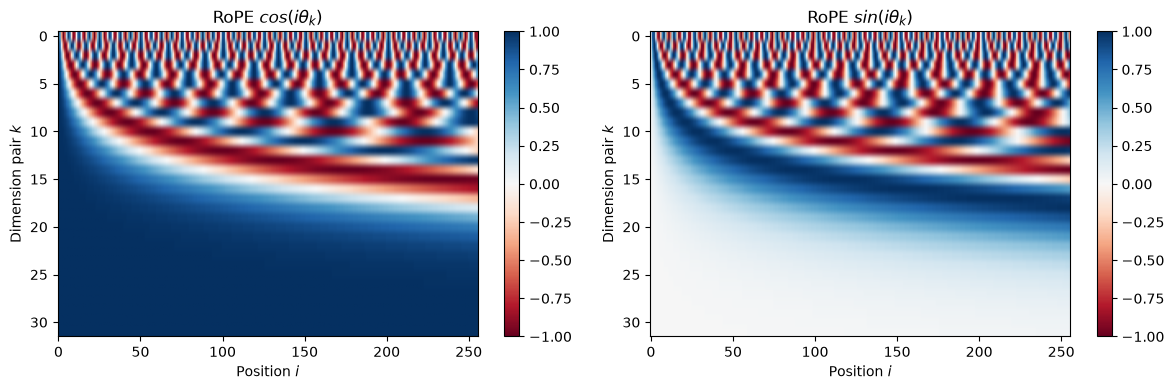

In [23]:
_viz_rope = RotaryPositionalEmbedding(d_head=64, max_seq_len=256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, values) in zip(axes, [("cos", _viz_rope.cos), ("sin", _viz_rope.sin)]):
    im = ax.imshow(values.T.numpy(), aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    ax.set_xlabel("Position $i$")
    ax.set_ylabel("Dimension pair $k$")
    ax.set_title(f"RoPE ${name}(i \\theta_k)$")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

<a id='section3_4'></a>
## 3.4 Scaled Dot-Product Attention

This part is unchanged from the original Transformer. Each input vector is mapped to query, key and
value vectors; the query at position $i$ is compared against every key $j$; the scores are passed
through a softmax and used to compute a weighted average of the values:

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling keeps the dot products from growing with dimension, which would otherwise
push the softmax into a saturated regime with vanishing gradients.

**Masking.** In a decoder model attention is *masked*: position $i$ may attend only to positions
$j \le i$. Without this, the model could look at the token it is trying to predict, which trivialises
the language modelling objective and would not match what happens at generation time.

We use the convention that a mask entry of `True` means "this query **does** attend to this key".
Computationally, masking is far cheaper than running attention separately on each prefix: we add
$-\infty$ to the pre-softmax scores wherever the mask is `False`, so those positions receive exactly
zero probability.

In [24]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Scaled dot-product attention.
    params:
        q:    (..., n_queries, d_k)
        k:    (..., n_keys, d_k)
        v:    (..., n_keys, d_v)
        mask: optional boolean (n_queries, n_keys); True = attend, False = do not attend
    returns:
        out:  (..., n_queries, d_v)
    """
    d_k = q.size(-1)

    # Step 1: scores e_ij = q_i . k_j / sqrt(d_k)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)        # (..., n_queries, n_keys)

    # Step 2: block the disallowed positions with -inf so softmax gives them zero weight
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))

    # Step 3: normalise over the KEY dimension, then take the weighted average of values
    attn = F.softmax(scores, dim=-1)                         # (..., n_queries, n_keys)
    return attn @ v                                          # (..., n_queries, d_v)

In [25]:
torch.manual_seed(0)
_q = torch.randn(2, 4, 6, 16)      # (batch, heads, queries, d_k)
_k = torch.randn(2, 4, 6, 16)
_v = torch.randn(2, 4, 6, 16)

# Build a causal mask: query i attends to key j only if j <= i.
_causal = torch.arange(6)[None, :] <= torch.arange(6)[:, None]
print("Causal mask (True = attend):")
print(_causal.int().numpy())

_out = scaled_dot_product_attention(_q, _k, _v, _causal)
print(f"\nOutput shape: {tuple(_out.shape)}  (batch-like dims preserved)")
assert _out.shape == _q.shape

# Check the mask really blocks the future: changing v at position 5 must not change output 0..4.
_v2 = _v.clone()
_v2[:, :, 5, :] = torch.randn(2, 4, 16)
_out2 = scaled_dot_product_attention(_q, _k, _v2, _causal)
print(f"Max change at positions 0-4 after editing position 5: "
      f"{(_out[:, :, :5] - _out2[:, :, :5]).abs().max().item():.2e}")
assert torch.allclose(_out[:, :, :5], _out2[:, :, :5], atol=1e-6)
print("\nAttention is correctly causal.")

Causal mask (True = attend):
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]

Output shape: (2, 4, 6, 16)  (batch-like dims preserved)
Max change at positions 0-4 after editing position 5: 0.00e+00

Attention is correctly causal.


<a id='section3_5'></a>
## 3.5 Causal Multi-Head Self-Attention with QK Norm

### Multi-head attention

A single attention head learns one way of relating positions — one similarity function over queries
and keys. But tokens relate in many ways at once, so a single head has to compromise. Multi-head
attention runs $h$ heads in parallel, each with its own projections:

$$\mathrm{MultiHeadSelfAttention}(x) = W_O \,\mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h),
\qquad \mathrm{head}_c = \mathrm{Attention}(W_Q^c x,\, W_K^c x,\, W_V^c x)$$

Following the standard sizing convention from the lecture, $d_q = d_k = d_v = d / h$. With this
choice the total parameter count and computation stay roughly the same as a single head at full
width.

In practice we do not build $h$ separate modules. We use one $W_Q$, one $W_K$ and one $W_V$ of full
width, then *reshape* the output into $h$ heads. This results in three matrix multiplies instead of $3h$, with
identical maths.

### QK norm

Inserting more layer norms into the architecture further improves training stability. It has become
common to normalise the queries and keys before computing attention scores — **QK norm**. This
bounds the magnitude of $q$ and $k$, which stops the pre-softmax logits from growing large enough to
saturate the softmax (a known cause of loss spikes when training large models).

We apply an RMSNorm over the `d_head` dimension of each head, *before* RoPE. (Ordering conventions
differ between implementations regarding normalising before or after applying RoPE.)

### Putting it together

The forward pass, in order:

1. Project $x$ to $q$, $k$ and $v$; no biases.
2. Reshape to `(batch, n_heads, seq_len, d_head)`.
3. Apply QK norm to $q$ and $k$.
4. Apply RoPE to $q$ and $k$ (**not** to $v$), with the head dimension treated as a batch dimension
   so that the *same* rotation is used for every head.
5. Causal scaled dot-product attention.
6. Concatenate the heads and apply the output projection $W_O$.

In [26]:
class CausalSelfAttention(nn.Module):
    """
    Causal multi-head self-attention with QK norm and RoPE.
    params:
        d_model:     model dimension
        n_heads:     number of attention heads
        rope:        a shared RotaryPositionalEmbedding module
        use_qk_norm: whether to RMSNorm the queries and keys before attention
    """

    def __init__(self, d_model, n_heads, rope, use_qk_norm=True):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head = d_model // n_heads          # d_q = d_k = d_v = d_model / n_heads

        # One full-width projection each; the heads are carved out by reshaping.
        # No bias terms, following modern LLMs.
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)

        self.rope = rope
        self.q_norm = RMSNorm(self.d_head) if use_qk_norm else nn.Identity()
        self.k_norm = RMSNorm(self.d_head) if use_qk_norm else nn.Identity()

    def forward(self, x):
        """
        params:
            x: (batch, seq_len, d_model)
        returns:
            (batch, seq_len, d_model)
        """
        batch, seq_len, _ = x.shape
        positions = torch.arange(seq_len, device=x.device)

        # Step 1: project, then split into heads -> (batch, n_heads, seq_len, d_head)
        q = self.q_proj(x).view(batch, seq_len, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k_proj(x).view(batch, seq_len, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(x).view(batch, seq_len, self.n_heads, self.d_head).transpose(1, 2)

        # Step 2: QK norm, then RoPE on queries and keys only (never on values)
        q, k = self.q_norm(q), self.k_norm(k)
        q, k = self.rope(q, positions), self.rope(k, positions)

        # Step 3: causal mask - query i attends to key j only if j <= i
        mask = positions[None, :] <= positions[:, None]              # (seq_len, seq_len)

        out = scaled_dot_product_attention(q, k, v, mask)            # (b, n_heads, seq_len, d_head)

        # Step 4: concatenate the heads and project back to the residual stream
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, -1)
        return self.o_proj(out)

In [27]:
torch.manual_seed(0)
_d_model, _n_heads = 128, 8
_rope_test = RotaryPositionalEmbedding(_d_model // _n_heads, max_seq_len=64)
_attn = CausalSelfAttention(_d_model, _n_heads, _rope_test)

_x = torch.randn(2, 10, _d_model)
_out = _attn(_x)
print(f"Input shape:  {tuple(_x.shape)}")
print(f"Output shape: {tuple(_out.shape)}")
assert _out.shape == _x.shape

# Causality: changing the input at position 6 onwards must not change outputs 0..5.
_x2 = _x.clone()
_x2[:, 6:, :] = torch.randn(2, 4, _d_model)
print(f"\nMax change at positions 0-5 after editing positions 6+: "
      f"{(_attn(_x) - _attn(_x2))[:, :6].abs().max().item():.2e}")
assert torch.allclose(_attn(_x)[:, :6], _attn(_x2)[:, :6], atol=1e-5)
print("Attention is causal.")

# The multi-head split keeps the parameter count the same as one full-width head.
_params = sum(p.numel() for p in _attn.parameters())
print(f"\nParameters for {_n_heads} heads of size {_d_model // _n_heads}: {_params:,}")
print(f"Four {_d_model}x{_d_model} projections would be: {4 * _d_model * _d_model:,}")

Input shape:  (2, 10, 128)
Output shape: (2, 10, 128)

Max change at positions 0-5 after editing positions 6+: 0.00e+00
Attention is causal.

Parameters for 8 heads of size 16: 65,568
Four 128x128 projections would be: 65,536


<a id='section3_6'></a>
## 3.6 The Pre-Norm Transformer Block

The Transformer block connects multi-head attention and the feed-forward network with residual
connections and layer normalisation. Most LLMs change the *order* of these operations compared to
the original Transformer.

**Post-norm** (original): normalisation is applied to the output of each sub-layer, *inside* the
residual path:

$$y = \mathrm{Norm}(x + \mathrm{Sublayer}(x))$$

**Pre-norm** (modern): normalisation is applied to the *input* of each sub-layer, *outside* the
residual path:

$$
\begin{aligned}
y &= x + \mathrm{MultiHeadSelfAttention}(\mathrm{RMSNorm}(x)) \\
z &= y + \mathrm{FFN}(\mathrm{RMSNorm}(y))
\end{aligned}
$$

This leads to more stable training for large networks. Pre-norm leaves a clean
**residual stream** running from the input embeddings all the way to the final output with no
normalisation in the way, so gradients flow back to early layers unimpeded. With post-norm, every
layer's normalisation sits on that path.

Because the residual stream is never normalised inside the stack, its scale can grow with depth.
That is why a pre-norm model needs **one final normalisation** after the last block, before the
output projection — we add that in Section 3.7.

In [28]:
class TransformerBlock(nn.Module):
    """
    Pre-norm Transformer block: attention sub-layer then feed-forward sub-layer.
    params:
        d_model, n_heads, d_ff: sizes
        rope:        shared RotaryPositionalEmbedding module
        use_qk_norm: passed through to the attention module
    """

    def __init__(self, d_model, n_heads, d_ff, rope, use_qk_norm=True):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, rope, use_qk_norm)
        self.ffn_norm = RMSNorm(d_model)
        self.ffn = SwiGLU(d_model, d_ff)

    def forward(self, x):
        """
        params:
            x: (batch, seq_len, d_model)
        returns:
            (batch, seq_len, d_model)
        """
        # Sub-layer 1: normalise, attend, add the residual.
        x = x + self.attn(self.attn_norm(x))
        # Sub-layer 2: normalise, feed-forward, add the residual.
        x = x + self.ffn(self.ffn_norm(x))
        return x

In [29]:
torch.manual_seed(0)
_rope_test = RotaryPositionalEmbedding(128 // 8, max_seq_len=64)
_block = TransformerBlock(d_model=128, n_heads=8, d_ff=compute_d_ff(128), rope=_rope_test)

_x = torch.randn(2, 10, 128)
_out = _block(_x)
print(f"Input shape:  {tuple(_x.shape)}")
print(f"Output shape: {tuple(_out.shape)}  (identical, so blocks stack)")
assert _out.shape == _x.shape

# The residual stream should dominate at initialisation: the block starts close to the identity,
# which is part of why deep pre-norm stacks train stably.
print(f"\n||x||            = {_x.norm().item():.2f}")
print(f"||block(x) - x|| = {(_out - _x).norm().item():.2f}   (the sub-layer contribution)")
print("\nTransformer block looks correct.")

Input shape:  (2, 10, 128)
Output shape: (2, 10, 128)  (identical, so blocks stack)

||x||            = 52.05
||block(x) - x|| = 12.42   (the sub-layer contribution)

Transformer block looks correct.


<a id='section3_7'></a>
## 3.7 The Full Transformer LM

Now we assemble everything. Given a batch of token IDs of shape `(batch, seq_len)`, the model:

1. looks up a **token embedding** for each ID, producing `(batch, seq_len, d_model)`;
2. passes it through `n_layers` pre-norm Transformer blocks;
3. applies the **final RMSNorm** (needed because the residual stream is never normalised inside the
   stack);
4. applies the **LM head**, a linear projection to `vocab_size`, producing the next-token **logits**
   of shape `(batch, seq_len, vocab_size)`.

There is no positional embedding at the input: with RoPE, position is injected inside every
attention layer instead.

The output at position $i$ is the model's prediction of the token at position $i+1$. Because
attention is causal, a single forward pass gives us predictions for *every* prefix at once, which is
what makes training efficient.

### Parameter initialisation

Bad initialisation can cause vanishing or exploding gradients. Pre-norm Transformers are unusually
robust to this, but it still affects training speed and convergence. We use:

* **Linear weights:** $\mathcal{N}(0, \sigma^2)$ with $\sigma^2 = \frac{2}{d_{in} + d_{out}}$,
  truncated at $[-3\sigma, 3\sigma]$. This is Xavier/Glorot scaling — it keeps the variance of
  activations roughly constant as they pass through a layer. Truncation avoids rare extreme values.
* **Embeddings:** $\mathcal{N}(0, 1)$ truncated at $[-3, 3]$.
* **RMSNorm gains:** all ones (already the default in our `RMSNorm`).

We use `torch.nn.init.trunc_normal_` for the truncated normals.

In [30]:
@dataclass
class TransformerConfig:
    vocab_size: int = 1500
    context_length: int = 256      # maximum sequence length
    n_layers: int = 4
    d_model: int = 256
    n_heads: int = 8
    d_ff: int = 704                # ~ (8/3) * d_model, rounded to a multiple of 64
    rope_theta: float = 10000.0
    use_qk_norm: bool = True

In [31]:
class TransformerLM(nn.Module):
    """
    A decoder-only Transformer language model in the modern dense style.
    params:
        config: a TransformerConfig
    """

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_embeddings = nn.Embedding(config.vocab_size, config.d_model)

        # One RoPE module shared by every layer: the cos/sin tables are identical everywhere,
        # so there is no reason to store them more than once.
        self.rope = RotaryPositionalEmbedding(
            d_head=config.d_model // config.n_heads,
            max_seq_len=config.context_length,
            theta=config.rope_theta,
        )

        self.layers = nn.ModuleList([
            TransformerBlock(config.d_model, config.n_heads, config.d_ff,
                             self.rope, config.use_qk_norm)
            for _ in range(config.n_layers)
        ])

        self.final_norm = RMSNorm(config.d_model)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            std = math.sqrt(2.0 / (module.in_features + module.out_features))
            nn.init.trunc_normal_(module.weight, std=std, a=-3 * std, b=3 * std)
        elif isinstance(module, nn.Embedding):
            nn.init.trunc_normal_(module.weight, std=1.0, a=-3.0, b=3.0)

    def forward(self, token_ids):
        """
        params:
            token_ids: (batch, seq_len) integer token IDs
        returns:
            logits: (batch, seq_len, vocab_size)
        """
        # Step 1: embed the token IDs. No positional embedding - RoPE handles position.
        x = self.token_embeddings(token_ids)              # (batch, seq_len, d_model)

        # Step 2: run the stack of pre-norm blocks
        for layer in self.layers:
            x = layer(x)                                  # (batch, seq_len, d_model)

        # Step 3: final norm, then project to vocabulary logits
        return self.lm_head(self.final_norm(x))           # (batch, seq_len, vocab_size)

    def num_parameters(self, non_embedding=False):
        """Total parameter count; optionally excluding the embedding and LM head."""
        total = sum(p.numel() for p in self.parameters())
        if non_embedding:
            total -= self.token_embeddings.weight.numel() + self.lm_head.weight.numel()
        return total

Let us build the model we will actually train, and check its shapes and parameter budget.

In [32]:
config = TransformerConfig(
    vocab_size=len(vocab),
    context_length=256,
    n_layers=4,
    d_model=256,
    n_heads=8,
    d_ff=compute_d_ff(256),
    rope_theta=10000.0,
    use_qk_norm=True,
)
print(config)

torch.manual_seed(42)
model = TransformerLM(config).to(device)

_ids = torch.randint(0, config.vocab_size, (2, 16), device=device)
_logits = model(_ids)
print(f"\nInput shape:  {tuple(_ids.shape)}")
print(f"Logits shape: {tuple(_logits.shape)}   (batch, seq_len, vocab_size)")

print(f"\nTotal parameters:         {model.num_parameters():,}")
print(f"Non-embedding parameters: {model.num_parameters(non_embedding=True):,}")

print("\nParameter breakdown:")
_embed = model.token_embeddings.weight.numel()
_head = model.lm_head.weight.numel()
_attn = sum(p.numel() for l in model.layers for p in l.attn.parameters())
_ffn = sum(p.numel() for l in model.layers for p in l.ffn.parameters())
_norms = model.num_parameters() - _embed - _head - _attn - _ffn
for _name, _count in [("token embeddings", _embed), ("attention", _attn),
                      ("feed-forward", _ffn), ("LM head", _head), ("norms", _norms)]:
    print(f"  {_name:18} {_count:10,}  ({100 * _count / model.num_parameters():5.1f}%)")

TransformerConfig(vocab_size=1500, context_length=256, n_layers=4, d_model=256, n_heads=8, d_ff=704, rope_theta=10000.0, use_qk_norm=True)

Input shape:  (2, 16)
Logits shape: (2, 16, 1500)   (batch, seq_len, vocab_size)

Total parameters:         3,981,824
Non-embedding parameters: 3,213,824

Parameter breakdown:
  token embeddings      384,000  (  9.6%)
  attention           1,048,832  ( 26.3%)
  feed-forward        2,162,688  ( 54.3%)
  LM head               384,000  (  9.6%)
  norms                   2,304  (  0.1%)


Notice that the feed-forward layers hold more parameters than attention. In our small model the embeddings
and LM head are also a large share, but that fraction shrinks rapidly as models get deeper and
wider.

Now two correctness tests that matter for the whole architecture.

**Test 1 — causality.** If we change tokens from position $t$ onwards, the logits at positions
$< t$ must be *bit-for-bit* unchanged. If this fails, the model can see the future and the training
objective is meaningless.

**Test 2 — prefix consistency.** Running the model on a prefix must give the same logits as running
it on the full sequence and slicing. This checks that RoPE positions and the causal mask are built
consistently regardless of input length — the property that will later make a KV cache possible.

In [33]:
model.eval()
_ids = torch.randint(0, config.vocab_size, (2, 24), device=device)

# --- Test 1: causality
with torch.no_grad():
    _logits_a = model(_ids)
    _ids_b = _ids.clone()
    _ids_b[:, 12:] = torch.randint(0, config.vocab_size, (2, 12), device=device)
    _logits_b = model(_ids_b)
_diff = (_logits_a[:, :12] - _logits_b[:, :12]).abs().max().item()
print(f"Test 1 - causality: max logit difference on the unchanged prefix = {_diff:.2e}")
assert _diff == 0.0, "Model is not causal!"

# --- Test 2: a shorter input gives the same logits as slicing a longer one
with torch.no_grad():
    _logits_prefix = model(_ids[:, :10])
_diff = (_logits_a[:, :10] - _logits_prefix).abs().max().item()
print(f"Test 2 - prefix consistency: max difference = {_diff:.2e}")
assert _diff < 1e-4, "Logits depend on how much context was passed in!"

# --- Sanity check on the initial loss
with torch.no_grad():
    _loss = F.cross_entropy(_logits_a.reshape(-1, config.vocab_size), _ids.reshape(-1))
print(f"\nInitial loss: {_loss.item():.3f}  (uniform guess would be "
      f"ln({config.vocab_size}) = {math.log(config.vocab_size):.3f})")
print("\nThe full model looks correct.")
model.train()
print()

Test 1 - causality: max logit difference on the unchanged prefix = 0.00e+00
Test 2 - prefix consistency: max difference = 1.67e-06

Initial loss: 7.435  (uniform guess would be ln(1500) = 7.313)

The full model looks correct.



The initial loss should be close to $\ln(|V|)$ — a freshly initialised model knows nothing, so it
should be about as good as guessing uniformly. This is a quick and surprisingly effective way to
catch initialisation bugs: a much *larger* initial loss usually means the weights are too big, and a
much *smaller* one usually means something is leaking information.

<a id='section4'></a>
# 4. Training

We now have a tokenized corpus and a model. What remains are: a way to sample
batches, a way to save and restore progress, and the training loop itself.

> We use plain **stochastic gradient descent** with a fixed learning
> rate. This is enough to see the model learn, and it keeps the loop small enough to read in one
> go. It is *not* how you would train an LLM in practice. The assignment adds the AdamW optimiser,
> learning-rate warmup and cosine decay, and gradient clipping — and you will be able to measure
> exactly how much each of them helps, using the baseline you establish here.

<a id='section4_1'></a>
## 4.1 Batched Data Loader

Our tokenized data is one long sequence $x = (x_1, \ldots, x_n)$ — all documents concatenated, with
`<|endoftext|>` between them. A data loader turns this into batches of $B$ sequences of length $m$,
each paired with the corresponding next tokens. For $B = 1, m = 3$, one possible batch is
$([x_2, x_3, x_4],\ [x_3, x_4, x_5])$.

The targets are simply the inputs shifted one position to the left. Because attention is causal, one
forward pass over a length-$m$ input produces $m$ next-token predictions, one per prefix — so every
position in every sequence contributes to the loss.

This flat-concatenation layout simplifies things considerably:

* **Sampling is trivial:** any start index $1 \le i \le n - m$ gives a valid training sequence.
* **No padding is needed**, because every sequence has exactly the same length. Padding wastes
  computation, so avoiding it improves hardware utilisation.
* **We never need the whole dataset in memory.** For a corpus that does not fit in RAM you would
  memory-map the array with `np.memmap` and index into it exactly as below. Ours is small enough
  that we can keep it in memory.

The one thing we give up is that a sampled sequence may straddle a document boundary. That is fine
— the `<|endoftext|>` token tells the model a document ended, and it learns to treat it as a reset.

In [34]:
def get_batch(token_ids, batch_size, context_length, device, rng):
    """
    Sample a batch of (input, target) sequences from a flat array of token IDs.
    params:
        token_ids:      1-D numpy array of token IDs
        batch_size:     number of sequences in the batch
        context_length: length of each sequence
        device:         torch device to place the tensors on
        rng:            a numpy random Generator
    returns:
        x: (batch_size, context_length) inputs
        y: (batch_size, context_length) targets, i.e. x shifted one position left
    """
    # Step 1: pick random start indices, leaving room for the target shifted one to the right
    max_start = len(token_ids) - context_length - 1
    starts = rng.integers(0, max_start, size=batch_size)

    # Step 2: slice out the inputs and the targets (inputs shifted by one)
    x = np.stack([token_ids[s:s + context_length] for s in starts])
    y = np.stack([token_ids[s + 1:s + 1 + context_length] for s in starts])

    # Step 3: convert to int64 tensors on the target device
    x = torch.from_numpy(x.astype(np.int64)).to(device)
    y = torch.from_numpy(y.astype(np.int64)).to(device)
    return x, y

In [35]:
_rng = np.random.default_rng(0)
_x, _y = get_batch(train_ids, batch_size=4, context_length=16, device=device, rng=_rng)

print(f"x shape: {tuple(_x.shape)}, dtype {_x.dtype}, device {_x.device}")
print(f"y shape: {tuple(_y.shape)}")

# The target must be the input shifted left by exactly one position.
assert torch.equal(_x[:, 1:], _y[:, :-1]), "y should be x shifted one position left"
print("\nTargets are inputs shifted by one.")

print(f"\nFirst sequence decoded:\n  input:  {tokenizer.decode(_x[0].tolist())!r}")
print(f"  target: {tokenizer.decode(_y[0].tolist())!r}")

x shape: (4, 16), dtype torch.int64, device mps:0
y shape: (4, 16)

Targets are inputs shifted by one.

First sequence decoded:
  input:  ' and tried to ride it. Tom watched and knew this was not a good idea'
  target: ' tried to ride it. Tom watched and knew this was not a good idea.'


<a id='section4_2'></a>
## 4.2 Checkpointing

Training runs get interrupted — jobs time out, machines fail, notebooks get restarted. We also often
want intermediate models afterwards, for example to sample from the model at different stages of
training and watch its output improve.

A checkpoint needs everything required to resume trianing:

* the **model weights** (`model.state_dict()`),
* the **optimizer state** — plain SGD is stateless, but AdamW keeps running moment estimates, so
  saving this becomes essential in the assignment,
* the **iteration number**, needed to resume a learning-rate schedule at the right point.

`torch.save` handles all of it; `state_dict()` / `load_state_dict()` do the model and optimizer
halves.

In [36]:
def save_checkpoint(model, optimizer, iteration, path):
    """Write everything needed to resume training to `path`."""
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "iteration": iteration,
        # Store the config as a plain dict rather than the dataclass object, so that loading
        # the checkpoint does not require the class definition to be importable.
        "config": asdict(model.config),
    }, path)


def load_checkpoint(path, model, optimizer=None):
    """
    Restore model (and optionally optimizer) state from `path`.
    returns:
        the iteration number stored in the checkpoint
    """
    checkpoint = torch.load(path, weights_only=True)
    model.load_state_dict(checkpoint["model"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer"])
    return checkpoint["iteration"]

In [37]:
os.makedirs("checkpoints", exist_ok=True)

_opt = torch.optim.SGD(model.parameters(), lr=0.1)
save_checkpoint(model, _opt, iteration=0, path="checkpoints/test.pt")

# Restore into a freshly initialised model and confirm the weights round-trip exactly.
_fresh = TransformerLM(config).to(device)
_before = (_fresh.lm_head.weight - model.lm_head.weight).abs().max().item()
_iteration = load_checkpoint("checkpoints/test.pt", _fresh, torch.optim.SGD(_fresh.parameters(), lr=0.1))
_after = (_fresh.lm_head.weight - model.lm_head.weight).abs().max().item()

print(f"Weight difference before loading: {_before:.4f}")
print(f"Weight difference after loading:  {_after:.4f}")
print(f"Restored iteration: {_iteration}")
assert _after == 0.0, "Checkpoint round trip failed"
print("\nCheckpointing works.")

Weight difference before loading: 0.1932
Weight difference after loading:  0.0000
Restored iteration: 0

Checkpointing works.


<a id='section4_3'></a>
## 4.3 The Training Loop

The training objective is **cross-entropy** between the predicted next-token distribution and the
true next token, averaged over every position in the batch:

$$\mathcal{L} = -\frac{1}{B \cdot m}\sum_{b=1}^{B}\sum_{i=1}^{m}
\log P(x^{(b)}_{i+1} \mid x^{(b)}_{1 \ldots i})$$

`F.cross_entropy` expects logits of shape `(N, vocab_size)` and targets of shape `(N,)`, so we
flatten the batch and sequence dimensions together. It also applies the log-softmax internally, in a
numerically stable way — so we pass it raw **logits**, never softmax probabilities.

Cross-entropy in nats relates to **perplexity** as
$\mathrm{PPL} = e^{\mathcal{L}}$, the effective number of tokens the model is choosing between at
each step. A loss of $\ln(1500) \approx 7.31$ means "no idea, all 1500 tokens equally likely".

Each step is standard for PyTorch training: get a batch, forward, compute loss, backward, step.
We evaluate on held-out data periodically to watch for overfitting.

In [38]:
@torch.no_grad()
def estimate_loss(model, token_ids, batch_size, context_length, device, n_batches=10, seed=1234):
    """Average loss over several batches, with the model in eval mode."""
    model.eval()
    rng = np.random.default_rng(seed)     # fixed seed => comparable across evaluations
    total = 0.0
    for _ in range(n_batches):
        x, y = get_batch(token_ids, batch_size, context_length, device, rng)
        logits = model(x)
        total += F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1)).item()
    model.train()
    return total / n_batches

In [39]:
def train(model, train_ids, val_ids, num_steps, batch_size, learning_rate,
          eval_every=50, checkpoint_path="checkpoints/model.pt", seed=0):
    """
    Train the model with plain SGD.
    returns:
        history: dict with 'step', 'train_loss' and 'val_loss' lists
    """
    context_length = model.config.context_length
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    rng = np.random.default_rng(seed)
    history = {"step": [], "train_loss": [], "val_loss": []}

    model.train()
    start = time.time()
    for step in range(1, num_steps + 1):
        # Step 1: sample a batch of inputs and targets
        x, y = get_batch(train_ids, batch_size, context_length, device, rng)

        # Step 2: forward pass -> logits of shape (batch, seq_len, vocab_size)
        logits = model(x)

        # Step 3: cross-entropy loss, flattening batch and sequence together
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

        # Step 4: backward pass and parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % eval_every == 0 or step == 1:
            val_loss = estimate_loss(model, val_ids, batch_size, context_length, device,
                                     n_batches=5)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss)
            print(f"step {step:5d} | train loss {loss.item():.4f} | val loss {val_loss:.4f} "
                  f"| perplexity {math.exp(val_loss):7.1f} | {time.time() - start:5.0f}s")

    save_checkpoint(model, optimizer, num_steps, checkpoint_path)
    print(f"\nSaved checkpoint to {checkpoint_path}")
    return history

### Sanity check: overfit a single batch

Before starting a real run, always check that the model can **overfit a single batch**. If the
implementation is correct, repeatedly training on the same handful of sequences should drive the
loss towards zero — the model can simply memorise them. If the loss gets stuck, there is a bug
(commonly a mis-shaped loss, a detached gradient, or a broken mask), and no amount of training on
the full dataset will fix it.

This is the single most valuable debugging habit when developing model architectures.

In [40]:
torch.manual_seed(0)
_debug_model = TransformerLM(config).to(device)
_debug_opt = torch.optim.SGD(_debug_model.parameters(), lr=0.5)

# One fixed batch, reused every step.
_x, _y = get_batch(train_ids, batch_size=4, context_length=64, device=device,
                   rng=np.random.default_rng(0))

print(f"Overfitting a single batch (loss should fall well below "
      f"ln({config.vocab_size}) = {math.log(config.vocab_size):.2f}):")
for _step in range(1, 201):
    _logits = _debug_model(_x)
    _loss = F.cross_entropy(_logits.reshape(-1, config.vocab_size), _y.reshape(-1))
    _debug_opt.zero_grad()
    _loss.backward()
    _debug_opt.step()
    if _step % 40 == 0:
        print(f"  step {_step:3d}: loss {_loss.item():.4f}")

assert _loss.item() < 4.0, "Model cannot overfit a single batch - there is probably a bug"
print("\nThe model can fit a single batch, so the plumbing is sound.")
del _debug_model, _debug_opt

Overfitting a single batch (loss should fall well below ln(1500) = 7.31):
  step  40: loss 0.0293
  step  80: loss 0.0113
  step 120: loss 0.0069
  step 160: loss 0.0049
  step 200: loss 0.0038

The model can fit a single batch, so the plumbing is sound.


<a id='section4_4'></a>
## 4.4 Training the Model

Now we train for real. With the settings below, expect roughly 4 minutes on an Apple Silicon GPU
(MPS) or a CUDA GPU, and about 6 minutes on CPU. Reduce `NUM_STEPS` if you want a faster pass
through the notebook, or raise it if you want better samples.

**Learning rate:** `0.3` is a reasonable value for plain SGD *for this model*. It is worth
appreciating how fragile that is: at `0.5` this exact setup trains noticeably *worse*, spiking early
and never fully recovering, because there is nothing to damp a large gradient step. Learning-rate
warmup and gradient clipping can fix that, and AdamW's per-parameter scaling makes
the choice far less delicate.

In [41]:
NUM_STEPS = 600
BATCH_SIZE = 32
LEARNING_RATE = 0.3

torch.manual_seed(42)
model = TransformerLM(config).to(device)
print(f"Training {model.num_parameters():,} parameters on {device}")
print(f"Tokens processed: {NUM_STEPS * BATCH_SIZE * config.context_length:,}\n")

history = train(
    model, train_ids, val_ids,
    num_steps=NUM_STEPS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_every=50,
    checkpoint_path="checkpoints/tinystories.pt",
)

Training 3,981,824 parameters on mps
Tokens processed: 4,915,200

step     1 | train loss 7.4626 | val loss 7.2769 | perplexity  1446.4 |     2s
step    50 | train loss 5.0719 | val loss 5.1146 | perplexity   166.4 |    26s
step   100 | train loss 4.7560 | val loss 4.8184 | perplexity   123.8 |    52s
step   150 | train loss 4.5425 | val loss 4.5977 | perplexity    99.3 |    76s
step   200 | train loss 4.2321 | val loss 4.3783 | perplexity    79.7 |   101s
step   250 | train loss 4.1701 | val loss 4.2428 | perplexity    69.6 |   125s
step   300 | train loss 4.1657 | val loss 4.1130 | perplexity    61.1 |   149s
step   350 | train loss 4.0817 | val loss 3.9986 | perplexity    54.5 |   177s
step   400 | train loss 3.8187 | val loss 3.9181 | perplexity    50.3 |   201s
step   450 | train loss 3.8625 | val loss 3.8466 | perplexity    46.8 |   225s
step   500 | train loss 3.7936 | val loss 3.7787 | perplexity    43.8 |   250s
step   550 | train loss 3.6320 | val loss 3.7447 | perplexity    

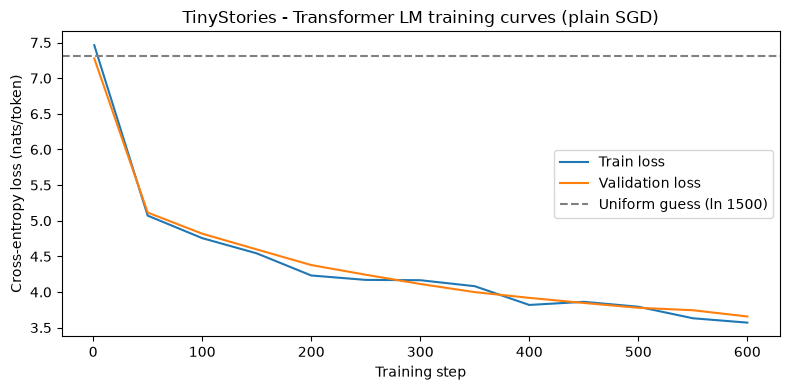

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(history["step"], history["train_loss"], label="Train loss")
plt.plot(history["step"], history["val_loss"], label="Validation loss")
plt.axhline(math.log(config.vocab_size), color="grey", linestyle="--",
            label=f"Uniform guess (ln {config.vocab_size})")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss (nats/token)")
plt.title("TinyStories - Transformer LM training curves (plain SGD)")
plt.legend()
plt.tight_layout()
plt.show()

**Questions to consider:**

* Train and validation loss should track each other closely. What does that tell you about whether
  this model is overfitting, and what would you change if you wanted it to?
* The curve is still clearly descending when we stop. What is the cheapest change that would get
  more out of the same wall-clock budget — more steps, a bigger model, or a better optimizer?
* Convert the final loss to perplexity. How many tokens is the model effectively choosing between
  at each step, out of 1500?

<a id='section5'></a>
# 5. Text Generation

To generate text we give the model a **prompt** $x_{1 \ldots t}$, take the predicted distribution at
the **final** position, sample a token from it, append it to the sequence, and repeat:

$$P(x_{t+1} = i \mid x_{1 \ldots t}) = \frac{\exp(v_i)}{\sum_j \exp(v_j)},
\qquad v = \mathrm{TransformerLM}(x_{1 \ldots t})_t$$

We stop when we generate `<|endoftext|>` or hit a maximum length.

Note that this computation is wasteful: at every step we re-run the model over the *entire* prefix,
recomputing keys and values that cannot have changed. Generating $n$ tokens therefore costs
$O(n^2)$ work. The fix is a **KV cache**, which you will implement in the assignment; it is the
single biggest lever on inference speed, and the reason for grouped-query attention.

## Temperature Sampling

Small models sometimes produce low-quality text, and the sampling strategy makes a real difference.
**Temperature scaling** divides the logits by a parameter $\tau$ before the softmax:

$$\mathrm{softmax}(v, \tau)_i = \frac{\exp(v_i / \tau)}{\sum_{j} \exp(v_j / \tau)}$$

* $\tau < 1$ **sharpens** the distribution: more conservative, more repetitive, more fluent.
* $\tau = 1$ samples from the model's distribution exactly as learned.
* $\tau > 1$ **flattens** it: more surprising, more prone to nonsense.
* $\tau \to 0$ concentrates all mass on the single most likely token, i.e. greedy decoding.


In [43]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=200, temperature=0.8, seed=None):
    """
    Autoregressively generate a continuation of `prompt`.
    params:
        model, tokenizer: the trained model and its tokenizer
        prompt:           starting string
        max_new_tokens:   maximum number of tokens to generate
        temperature:      sampling temperature; 0 means greedy decoding
        seed:             optional seed for reproducible sampling
    returns:
        the generated string, including the prompt
    """
    model.eval()
    context_length = model.config.context_length
    eot_id = tokenizer.token_to_id[END_OF_TEXT]

    generator = torch.Generator().manual_seed(seed) if seed is not None else None
    token_ids = tokenizer.encode(prompt)

    for _ in range(max_new_tokens):
        # Feed the whole context so far, truncated to what the model can handle
        model_input = torch.tensor([token_ids[-context_length:]], dtype=torch.long, device=device)
        logits = model(model_input)

        # Step 1: take the logits at the FINAL position - that is the next-token prediction
        next_logits = logits[0, -1, :].float()

        # Step 2: sample (or take the argmax if temperature is 0)
        if temperature == 0:
            next_id = int(next_logits.argmax())
        else:
            probs = F.softmax(next_logits / temperature, dim=-1).cpu()
            next_id = int(torch.multinomial(probs, num_samples=1, generator=generator))

        # Step 3: append it and stop if it ends the document
        token_ids.append(next_id)
        if next_id == eot_id:
            break

    return tokenizer.decode(token_ids)

Let us see what our model writes. Remember what it is: 3.7 million parameters, trained for a few
minutes with plain SGD on a few thousand stories. Expect broadly story-shaped English with
believable local syntax and shaky long-range coherence — names drift, plots do not resolve.

Sampling is random, so your output will differ from a neighbour's. Run these cells a few times.

In [44]:
for _temperature in [0.0, 0.5, 0.8, 1.2]:
    _label = "greedy" if _temperature == 0 else f"temperature {_temperature}"
    print(f"{'=' * 78}\n{_label}\n{'=' * 78}")
    print(generate(model, tokenizer, "Once upon a time", max_new_tokens=120,
                   temperature=_temperature, seed=1))
    print()

greedy
 Once upon a time, there was a little girl named Tim. Tim was a big, he was a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and a big, and

temperature 0.5
 Once upon a time, there was a little girl named Lucy. Every day, there was a little boy named Tim. The bird saw a big, there was a little boy named Tim. Tim was a big, but he was very happy to play with his friends. One day, he was very happy. Tim was a big tree with his friends. He wanted to play with his mom. He was very happy to the park to the bird. Tim was very happy. He had a new friend, Tim was very happy to play with his friends. Tim was very happy to play with his friends. Tim and said

temperature 0.8
 Once upon a time, there was a little boy named Lucy. Every loved to help the girl who wanted to

Compare the four samples. Greedy decoding ($\tau = 0$) usually falls into a repetitive loop — it is
deterministic, so any loop it enters it stays in. At $\tau = 1.2$ the text becomes adventurous and
starts producing malformed words. Somewhere in between is the useful range, which is why production
systems default to around $0.7$–$1.0$.

Try your own prompts below.

In [45]:
for _prompt in ["One day, a little girl named Lily", "The dog was very"]:
    print(f"{'=' * 78}\nPrompt: {_prompt!r}\n{'=' * 78}")
    print(generate(model, tokenizer, _prompt, max_new_tokens=120, temperature=0.8))
    print()

Prompt: 'One day, a little girl named Lily'
 One day, a little girl named Lily. Lily was walking and was very sad and went to his friends.<|endoftext|>

Prompt: 'The dog was very'
 The dog was very happy. The rock saw the shiny and said, "Thank you?" The robv is oridkinnes to the walk on the light long. The bird was free and said, "Yes," The cat said to the pary, the anyone. She was done, the puzzle and smiled, while, and said, "You can help you to different the park, Anna, came to help." The little boy and said out of the piferate. He said, "I can you sad, I will help you, it



<a id='section6'></a>
# 6. Summary and Next Steps

We built a complete modern LLM pipeline from scratch:

**Tokenization.** A character-level BPE tokenizer — pre-tokenization with word-start markers, the
merge-learning loop, and greedy segmentation — trained to a 1500-token vocabulary on TinyStories,
reaching about 3.6 characters per token.

**Architecture.** Every component that separates a modern dense LLM from the 2017 original:

| Component | Why it is there |
| --- | --- |
| RMSNorm | Faster than LayerNorm (less data movement), more stable training |
| Pre-norm blocks | Clean residual stream, stable training for deep networks |
| SwiGLU FFN, no biases | Better quality per parameter; $d_{ff} = \tfrac{8}{3}d$ keeps the budget fixed |
| RoPE | Relative position information, reinforced at every layer |
| Multi-head attention | Several relationships between positions captured at once |
| QK norm | Bounds attention logits, preventing loss spikes |

**Training and inference.** A batched data loader, checkpointing, an SGD training loop, and
temperature sampling — enough to train a 4M-parameter model to write recognisable children's
stories in a few minutes.

### What comes next

The assignment will build directly on this and fill in what we deliberately left out:

* **Optimisation:** the AdamW optimiser, learning-rate warmup and cosine decay, and gradient
  clipping — and measurements of how much each one is worth relative to the SGD baseline you just
  established.
* **Efficient inference:** a **KV cache**, so that generating $n$ tokens costs $O(n)$ work instead
  of $O(n^2)$, and **grouped-query attention (GQA)**, which shares key/value heads between query
  heads to shrink that cache. Neither changes what the model computes, which is why we could leave
  them out here — but together they are what makes generation practical at scale.
* **A faster BPE trainer:** incremental pair-count updates instead of recounting from scratch, so
  you can train on far more data.
* **Byte-level BPE:** removing the `<|unk|>` fallback entirely.
* **Experiments and ablations:** what happens if you remove RoPE, replace SwiGLU with SiLU, or
  switch from pre-norm back to post-norm?

### Things to try now

1. Set `use_qk_norm=False` in the config and retrain. Does anything change at this scale? Would you
   expect it to?
2. Vary `n_heads` between 1, 4 and 16 at fixed `d_model`. The parameter count barely moves — so
   what exactly are you trading off?
3. Retrain the tokenizer with `VOCAB_SIZE=500` and with `VOCAB_SIZE=5000`. How does the compression
   ratio change, and how does that change the amount of text the model sees in 600 steps?
4. Replace `torch.optim.SGD` with `torch.optim.AdamW(model.parameters(), lr=1e-3)` — a one-line
   change — and compare the loss curves. This previews the first part of the assignment.

### References

Papers on the main architecture components:

RoPE ([Su et al., 2021](https://arxiv.org/abs/2104.09864)), GQA
([Ainslie et al., 2023](https://arxiv.org/abs/2305.13245)), SwiGLU
([Shazeer, 2020](https://arxiv.org/abs/2002.05202)), RMSNorm
([Zhang and Sennrich, 2019](https://arxiv.org/abs/1910.07467)), pre-norm
([Xiong et al., 2020](https://arxiv.org/abs/2002.04745)), BPE
([Sennrich et al., 2016](https://arxiv.org/abs/1508.07909)), TinyStories
([Eldan and Li, 2023](https://arxiv.org/abs/2305.07759)).
